# Plotting Key Global Timeseries in ACCESS-OM3

This notebook uses the initial spinup simulation of ACCESS-OM3.

In [1]:
#parameters

### USER EDIT start
esm_file='/g/data/zv30/non-cmip/ACCESS-CM3/cm3-run-11-08-2025-25km-beta-om3-new-um-params/cm3-demo-datastore/cm3-demo-datastore.json'
dpi=300
### USER EDIT stop

import os
from matplotlib import rcParams
%matplotlib inline
rcParams['figure.dpi']= dpi

plotfolder=f"/g/data/{os.environ['PROJECT']}/{os.environ['USER']}/access-om3-paper-figs/"
os.makedirs(plotfolder, exist_ok=True)

 # a similar cell under this means it's being run in batch
print("ESM datastore path: ",esm_file)
print("Plot folder path: ",plotfolder)

ESM datastore path:  /g/data/zv30/non-cmip/ACCESS-CM3/cm3-run-11-08-2025-25km-beta-om3-new-um-params/cm3-demo-datastore/cm3-demo-datastore.json
Plot folder path:  /g/data/tm70/ek4684/access-om3-paper-figs/


In [2]:
import intake
from dask.distributed import Client
import matplotlib.pyplot as plt
import cmocean as cm
import cftime
import xarray as xr
xr.set_options(keep_attrs=True);  # cf_xarray works best when xarray keeps attributes by default
import warnings
warnings.filterwarnings('ignore')

In [3]:
client = Client(threads_per_worker=1)
print(client.dashboard_link)
client

/proxy/8787/status


Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: /proxy/8787/status,
Dashboard: /proxy/8787/status,Workers: 14
Total threads: 14,Total memory: 63.00 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:40381,Workers: 0
Dashboard: /proxy/8787/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:44003,Total threads: 1
Dashboard: /proxy/44451/status,Memory: 4.50 GiB
Nanny: tcp://127.0.0.1:39393,


## Load ACCESS-CM3 data from ESM datastore

In [4]:
datastore = intake.open_esm_datastore(
    esm_file,
    columns_with_iterables=[
        "variable",
        "variable_long_name",
        "variable_standard_name",
        "variable_cell_methods",
        "variable_units"
    ]
)

In [5]:
sosga = datastore.search(variable="soga", frequency="1mon").to_dask(
    xarray_combine_by_coords_kwargs = dict( # These kwargs can make things faster
        compat="override",
        data_vars="minimal",
        coords="minimal",
    ),
    xarray_open_kwargs = dict(
        chunks={"yh": -1, "xh": -1}, # Good for spatial operations, but not temporal
        decode_timedelta=True,
    use_cftime=True))['soga'].sel(time=slice(cftime.datetime(1981, 1, 16,calendar='proleptic_gregorian'), cftime.datetime(2017, 12, 16,calendar='proleptic_gregorian'))).resample(time = '1YE').mean('time').load()

In [6]:
thetaoga = datastore.search(variable="thetaoga", frequency="1mon").to_dask(
    xarray_combine_by_coords_kwargs = dict( # These kwargs can make things faster
        compat="override",
        data_vars="minimal",
        coords="minimal",
    ),
    xarray_open_kwargs = dict(
        chunks={"yh": -1, "xh": -1}, # Good for spatial operations, but not temporal
        decode_timedelta=True,
    use_cftime=True))['thetaoga'].sel(time=slice(cftime.datetime(1981, 1, 16,calendar='proleptic_gregorian'), cftime.datetime(2017, 12, 16,calendar='proleptic_gregorian'))).resample(time = '1YE').mean('time').load()

In [7]:
tos = datastore.search(variable="tos", frequency="1mon").to_dask(
    xarray_combine_by_coords_kwargs = dict( # These kwargs can make things faster
        compat="override",
        data_vars="minimal",
        coords="minimal",
    ),
    xarray_open_kwargs = dict(
        chunks={"yh": -1, "xh": -1}, # Good for spatial operations, but not temporal
        decode_timedelta=True,
    use_cftime=True))['tos'].resample(time = '1YE').mean('time').load()

## Load ACCESS-CM2 data from ACCESS-NRI Catalog

In [8]:
catalog = intake.cat.access_nri

In [9]:
var = catalog['bx944'].search(variable='temp_global_ave',frequency="1mon")

In [10]:
var = catalog['bx944'].search(variable='temp_global_ave',frequency="1mon")
temp_global_ave=var.to_dask(
            xarray_combine_by_coords_kwargs = dict( # These kwargs can make things faster
            compat="override",
            data_vars="minimal",
            coords="minimal",),
            xarray_open_kwargs=dict(
            chunks={"time": -1},
            decode_timedelta=True,
            use_cftime=True)
)['temp_global_ave'].resample(time = '1YE').mean('time').load()

In [11]:
temp_global_ave = temp_global_ave.sel(member='bx944')

In [12]:
var = catalog['bx944'].search(variable='salt_surface_ave',frequency="1mon")
salt_surface_ave=var.to_dask(
            xarray_combine_by_coords_kwargs = dict( # These kwargs can make things faster
            compat="override",
            data_vars="minimal",
            coords="minimal",),
            xarray_open_kwargs=dict(
            chunks={"time": -1},
            decode_timedelta=True,
            use_cftime=True)
)['salt_surface_ave'].resample(time = '1YE').mean('time').load()

In [13]:
salt_surface_ave = salt_surface_ave.sel(member='bx944')

In [14]:
var = catalog['bx944'].search(variable='ke_tot',frequency="1mon")
ke_tot=var.to_dask(
            xarray_combine_by_coords_kwargs = dict( # These kwargs can make things faster
            compat="override",
            data_vars="minimal",
            coords="minimal",),
            xarray_open_kwargs=dict(
            chunks={"time": -1},
            decode_timedelta=True,
            use_cftime=True)
)['ke_tot'].resample(time = '1YE').mean('time').load()

## Plot Timeseries

Text(0.5, 1.0, '(b) Global average sea surface salinity')

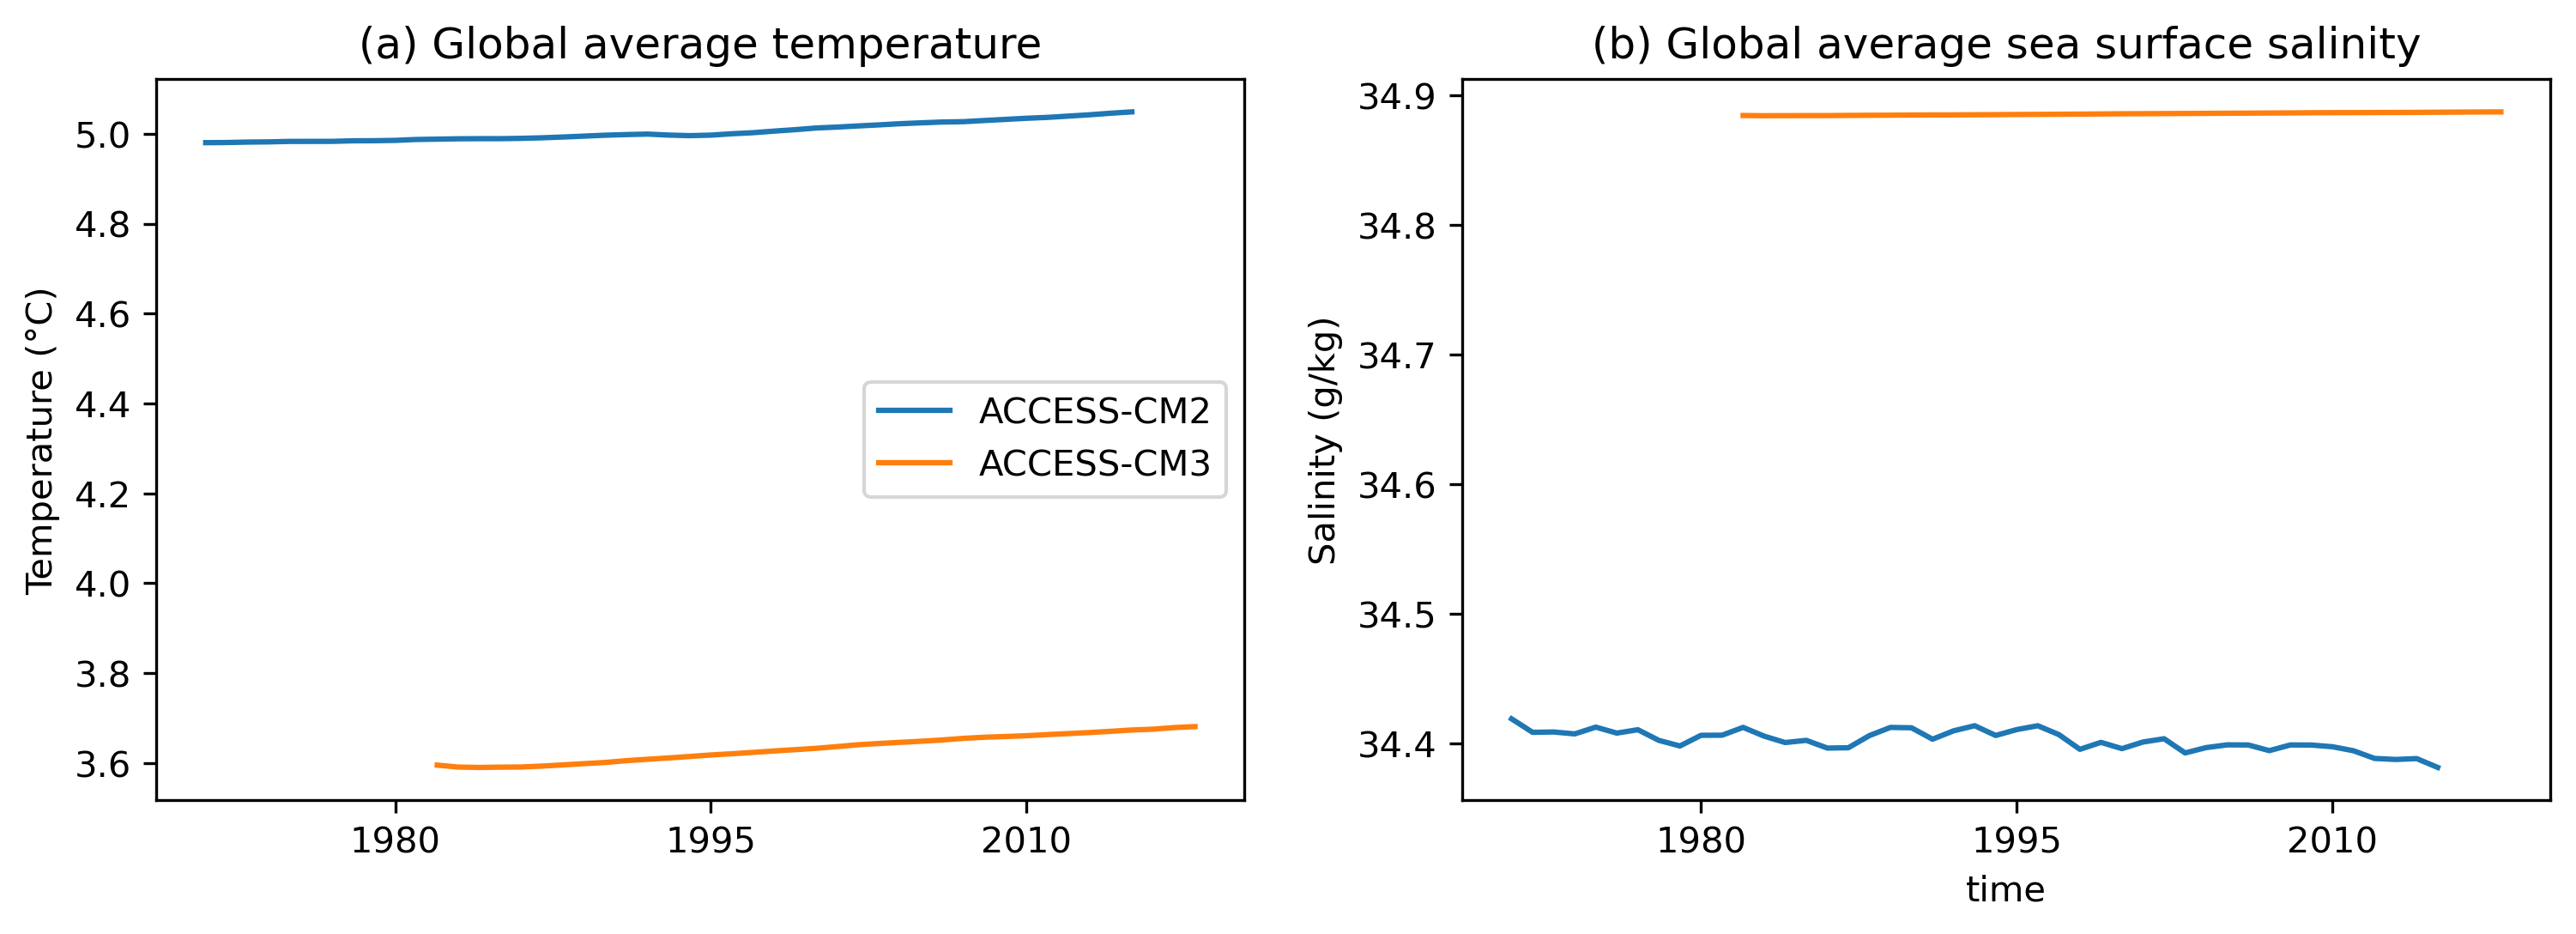

In [18]:
plt.figure(figsize=(12,8))

plt.subplot(221)
temp_global_ave.plot(label="ACCESS-CM2")
thetaoga.plot(label="ACCESS-CM3")
plt.legend()
plt.ylabel('Temperature (°C)')
plt.xlabel('')
plt.title('(a) Global average temperature')

plt.subplot(222)
salt_surface_ave.plot(label="ACCESS-CM2")
sosga.plot(label="ACCESS-CM3")
plt.ylabel('Salinity (g/kg)')
plt.title('(b) Global average sea surface salinity')

In [16]:
client.close()